# Journal_Model

Setup and Imports


In [1]:
!pip install nlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 20.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import nlp
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

%matplotlib inline

In [3]:
import sklearn
!python --version
print(f'TensorFlow: {tf.__version__}')
print(f'Scikit-learn: {sklearn.__version__}')
print(f'NLP: {nlp.__version__}')

Python 3.12.13
TensorFlow: 2.19.0
Scikit-learn: 1.6.1
NLP: 0.4.0


Load Data

In [4]:
df = pd.read_csv('Twitter Emotion Classification Dataset.csv', engine='python')

In [5]:
df

,text,label
0,i feel awful about it too because it s my job ...,0
1,im alone i feel awful,0
2,ive probably mentioned this before but i reall...,1
3,i was feeling a little low few days back,0
4,i beleive that i am much more sensitive to oth...,2
...,...,...
416804,that was what i felt when i was finally accept...,1
416805,i take every day as it comes i m just focussin...,4
416806,i just suddenly feel that everything was fake,0
416807,im feeling more eager than ever to claw back w...,1


In [6]:
df.head()

,text,label
0,i feel awful about it too because it s my job ...,0
1,im alone i feel awful,0
2,ive probably mentioned this before but i reall...,1
3,i was feeling a little low few days back,0
4,i beleive that i am much more sensitive to oth...,2


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    416809 non-null  object
 1   label   416809 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 6.4+ MB


In [8]:
df.isnull().sum()

,0
text,0
label,0


In [9]:
df.duplicated().sum()

np.int64(686)

In [10]:
df = df.drop_duplicates()
df.shape

(416123, 2)

### Get to know the Target Values
The original dataset map:

0: sadness
1: joy
2: love
3: anger
4: fear
5: surprise

In [11]:
labelMap = {0 : 'Sadness', 1 : 'Joy', 2 : 'Love', 3 : 'Anger', 4 : 'Fear', 5 : 'Surprise'}
target = df['label'].map(labelMap)

Text(0.5, 1.0, 'Countplot of Emotional State')

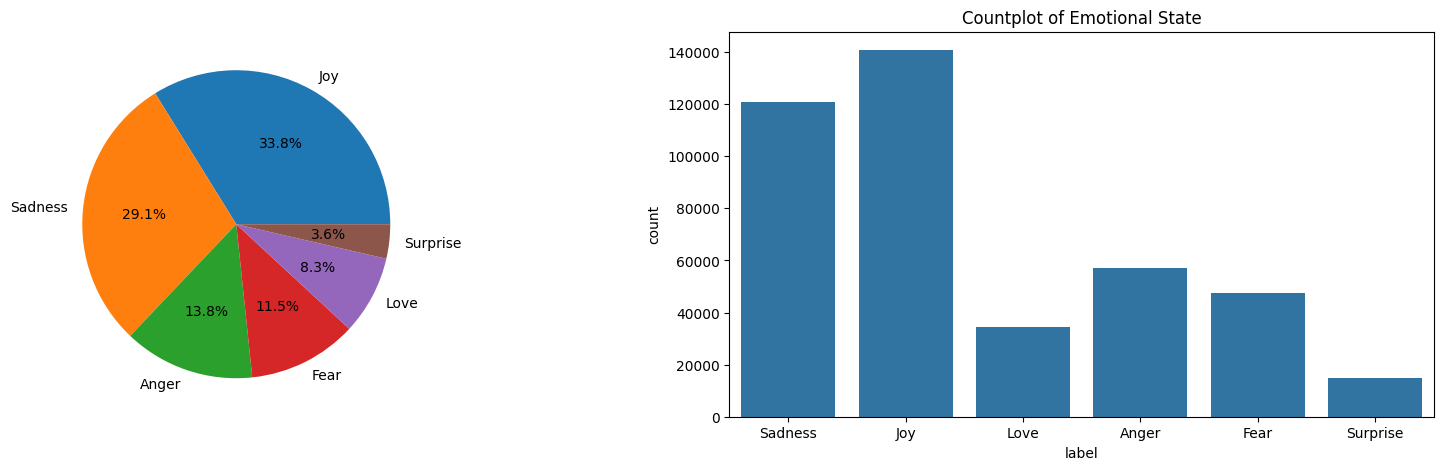

In [12]:
target_counts = target.value_counts()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

axes[0].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%')
plt.title('Emotional State Distribution')

sns.countplot(x=target, ax=axes[1])
axes[1].set_title('Countplot of Emotional State')

In [13]:
X = df.drop('label', axis=1)
y = df['label']

In [14]:
x_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(X_, y_, test_size=0.5, random_state=1, stratify=y_)

del X_, y_

print(f"the shape of the training set (input) is: {x_train.shape}")
print(f"the shape of the training set (target) is: {y_train.shape}\n")
print(f"the shape of the cross validation set (input) is: {x_val.shape}")
print(f"the shape of the cross validation set (target) is: {y_val.shape}\n")
print(f"the shape of the test set (input) is: {x_test.shape}")
print(f"the shape of the test set (target) is: {y_test.shape}")

the shape of the training set (input) is: (291286, 1)
the shape of the training set (target) is: (291286,)

the shape of the cross validation set (input) is: (62418, 1)
the shape of the cross validation set (target) is: (62418,)

the shape of the test set (input) is: (62419, 1)
the shape of the test set (target) is: (62419,)


## Tokenizer

1. Tokenizing the tweets

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [16]:
token = Tokenizer(num_words=10000, oov_token='<UNK>')
token.fit_on_texts(x_train['text'])

In [17]:
token.texts_to_sequences([x_train.iloc[1]['text']])

[[2, 3, 14, 2, 103, 5, 228, 42, 7, 610, 763, 551, 17, 134, 67]]

## Padding and Truncating Sequences

1. Checking length of the tweets
2. Creating padded sequences

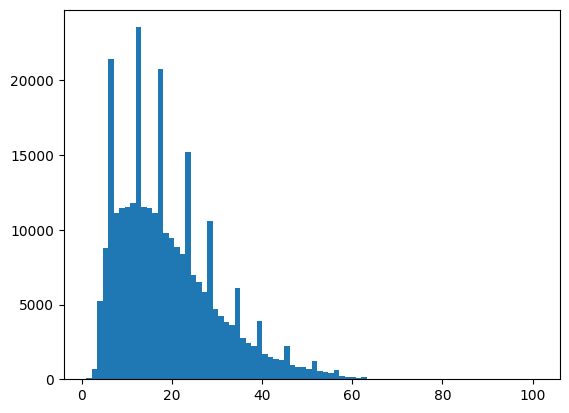

In [18]:
lengths = [len(t.split(' ')) for t in x_train['text']]
plt.hist(lengths, bins=len(set(lengths)))
plt.show()

In [19]:
maxlen = 150
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [20]:
def get_seq(tokenizer, tweets):
  seq = tokenizer.texts_to_sequences(tweets)
  padded = pad_sequences(seq, maxlen=maxlen, padding='post', truncating='post')
  return padded

In [21]:
pad_train_seq = get_seq(token, x_train['text'])

In [22]:
pad_train_seq[1]

array([  2,   3,  14,   2, 103,   5, 228,  42,   7, 610, 763, 551,  17,
       134,  67,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0], dtype=int32)

## Creating the Model

1. Creating the model
2. Compiling the model

In [23]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(10000, 128, input_length=maxlen),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [24]:
model.compile(
    loss = 'sparse_categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 150, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,273,748 (16.30 MB)

 Trainable params: 1,424,582 (5.43 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,849,166 (10.87 MB)

## Task 8: Training the Model

1. Preparing a validation set
2. Training the model

In [26]:
val_seq = get_seq(token, x_val['text'])

In [27]:
h = model.fit(
    pad_train_seq, y_train,
    validation_data=(val_seq, y_val),
    epochs=20,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2)]
)

Epoch 1/20
9103/9103 ━━━━━━━━━━━━━━━━━━━━ 257s 27ms/step - accuracy: 0.9120 - loss: 0.1907 - val_accuracy: 0.9394 - val_loss: 0.0970
Epoch 2/20
9103/9103 ━━━━━━━━━━━━━━━━━━━━ 253s 28ms/step - accuracy: 0.9408 - loss: 0.0957 - val_accuracy: 0.9403 - val_loss: 0.0910
Epoch 3/20
9103/9103 ━━━━━━━━━━━━━━━━━━━━ 249s 27ms/step - accuracy: 0.9416 - loss: 0.0904 - val_accuracy: 0.9411 - val_loss: 0.0904
Epoch 4/20
9103/9103 ━━━━━━━━━━━━━━━━━━━━ 248s 27ms/step - accuracy: 0.9429 - loss: 0.0866 - val_accuracy: 0.9413 - val_loss: 0.0908
Epoch 5/20
9103/9103 ━━━━━━━━━━━━━━━━━━━━ 247s 27ms/step - accuracy: 0.9434 - loss: 0.0847 - val_accuracy: 0.9397 - val_loss: 0.0965
Epoch 6/20
9103/9103 ━━━━━━━━━━━━━━━━━━━━ 247s 27ms/step - accuracy: 0.9439 - loss: 0.0834 - val_accuracy: 0.9410 - val_loss: 0.0942


## Task 9: Evaluating the Model

1. Visualizing training history
2. Prepraring a test set
3. A look at individual predictions on the test set
4. A look at all predictions on the test set

In [28]:
def show_history(h):
    epochs_trained = len(h.history['loss'])
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.plot(range(0, epochs_trained), h.history.get('accuracy'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_accuracy'), label='Validation')
    plt.ylim([0., 1.])
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(0, epochs_trained), h.history.get('loss'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_loss'), label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


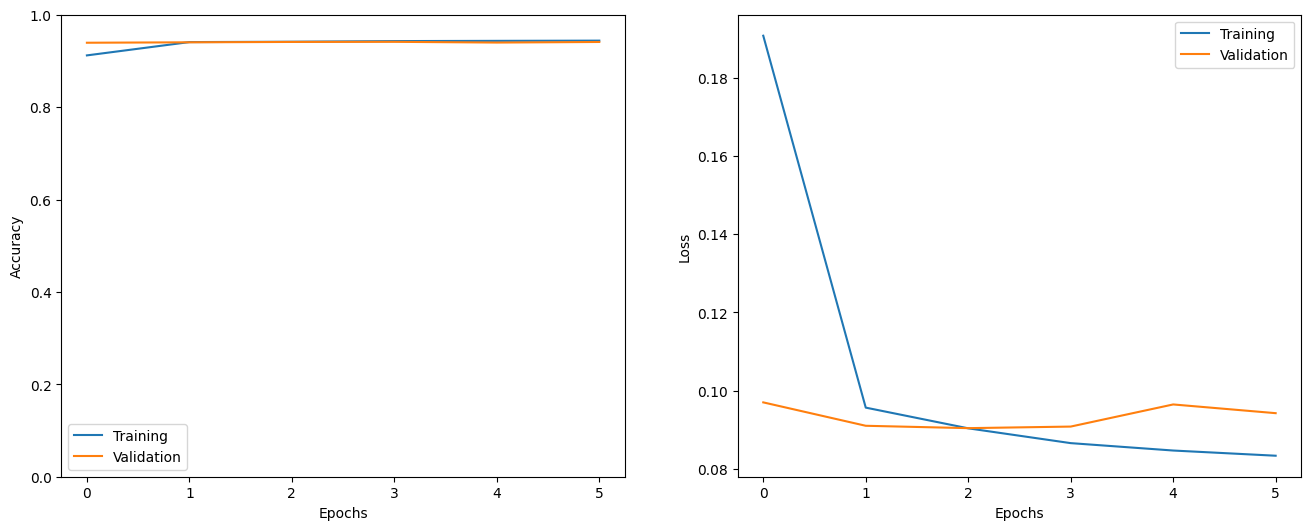

In [29]:
show_history(h)

In [30]:
test_seq = get_seq(token, x_test['text'])

In [31]:
_ = model.evaluate(test_seq, y_test)

1951/1951 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9414 - loss: 0.0925


In [32]:
i = random.randint(0, len(test_seq) - 1)

print('Sentence:', x_test.iloc[i]['text'])
print('Emotion:', labelMap[y_test.iloc[i]])

p = model.predict(np.expand_dims(test_seq[i], axis=0))[0]
pred_label_idx = np.argmax(p).astype('uint8')
pred_class = labelMap[pred_label_idx]

print('Predicted Emotion:', pred_class)

Sentence: i feel hated and ignored now
Emotion: Sadness
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
Predicted Emotion: Anger


In [33]:
preds = np.argmax(model.predict(test_seq), axis=-1)

1951/1951 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step


In [34]:
print("Prediction Results")
print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds, target_names=labelMap.values()))

Prediction Results
Accuracy: 0.9414441115685929
              precision    recall  f1-score   support

     Sadness       1.00      0.96      0.98     18149
         Joy       0.93      0.99      0.96     21117
        Love       1.00      0.71      0.83      5174
       Anger       0.94      0.95      0.94      8585
        Fear       0.85      0.99      0.91      7150
    Surprise       0.88      0.74      0.80      2244

    accuracy                           0.94     62419
   macro avg       0.93      0.89      0.90     62419
weighted avg       0.95      0.94      0.94     62419



In [35]:
from sklearn.metrics import f1_score

print("Macro F1:", f1_score(y_test, preds, average="macro"))
print("Weighted F1:", f1_score(y_test, preds, average="weighted"))

Macro F1: 0.9044811803531222
Weighted F1: 0.9400403710731609


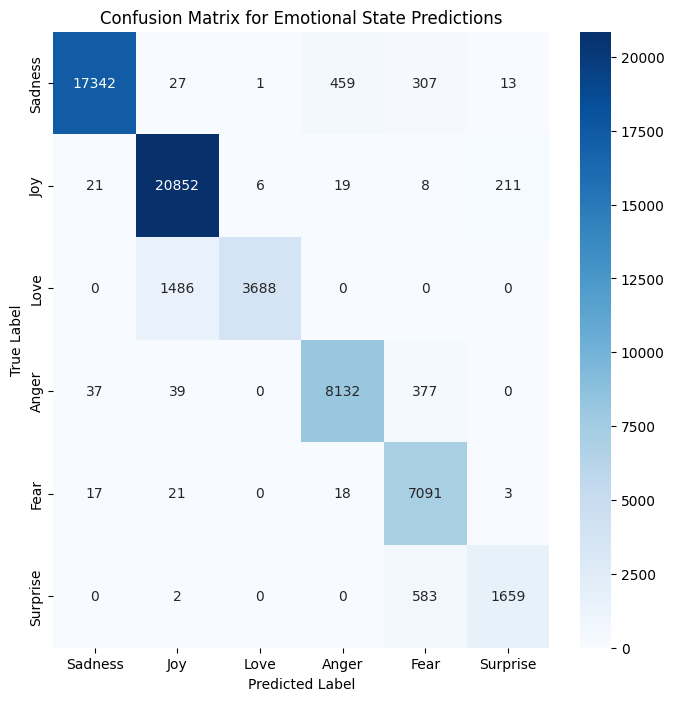

In [36]:
cm = confusion_matrix(y_test, preds, labels=list(labelMap.keys()))

plt.figure(figsize=(8, 8))
sp = plt.subplot(1, 1, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(labelMap.values()), yticklabels=list(labelMap.values()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Emotional State Predictions')

plt.show()

In [37]:
model.save("journal_model.h5")

import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(token, f)

In [38]:
model.save('journal_model.keras')

## Preprocess the input text

Apply the `get_seq` function to the input string `t` to tokenize and pad it into a format the model can understand. This will convert the raw text into a numerical sequence.


**Reasoning**:
The subtask requires converting the input string `t` into a list and then using the `get_seq` function with the `token` tokenizer to preprocess it. This code block directly addresses that instruction.



In [39]:
t = """Woke up feeling calm today. The sunrise was beautiful and I took some time to meditate. It's nice to start the day with intention...

This is where the full journal entry would continue. In a real application, the complete text would be stored and retrieved from the database.

I find that writing helps me process my thoughts and emotions. It's a safe space where I can be completely honest with myself without judgment.

Looking back at these entries helps me see patterns and growth over time. It's comforting to know that difficult moments pass and that I have the strength to work through challenges."""

print('Sentence:', t)

Sentence: Woke up feeling calm today. The sunrise was beautiful and I took some time to meditate. It's nice to start the day with intention...

This is where the full journal entry would continue. In a real application, the complete text would be stored and retrieved from the database.

I find that writing helps me process my thoughts and emotions. It's a safe space where I can be completely honest with myself without judgment.

Looking back at these entries helps me see patterns and growth over time. It's comforting to know that difficult moments pass and that I have the strength to work through challenges.


In [40]:
processed_text = get_seq(token, [t])
print(processed_text)

[[ 375   42    8  407  131    6 8501   21  624    4    2  492   72   53
     5 5560    1  488    5  204    6   97   25 2675   23   22  147    6
   446 1788 1915   64  677   12    7  319 2898    6 1120 1565   64   27
     1    4    1   60    6    1    2  165    9  270 1331   19  844   11
   433    4  680    1    7  402  877  147    2   41   27  251  816   25
    51  180 4712  280  102   34  115 3458 1331   19  113 3364    4 2280
   112   53    1 3428    5   44    9 1028  729 1114    4    9    2   18
     6 1312    5  122  149 2193    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0]]


**Reasoning**:
Now that the text has been preprocessed into a numerical sequence, the next step is to use the trained model to predict the emotion. This involves passing the `processed_text` to the `model.predict()` method, then using `np.argmax` to find the index of the highest probability, and finally mapping that index to the corresponding emotion label using `labelMap`.



In [41]:
p = model.predict(processed_text)[0]
pred_label_idx = np.argmax(p).astype('uint8')
pred_class = labelMap[pred_label_idx]

print('Predicted Emotion:', pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted Emotion: Joy
